# SlowBurn Demo

**Cost-Sustainable Concurrent Execution for Long-Horizon LLM Agents**

This notebook demonstrates SlowBurn end-to-end:

1. **Quick start** — two-line LLM setup with `create_llm()`
2. **Vision support** — send images to the LLM
3. **Global config** — `temp_config()` for environment-specific defaults
4. **Research agent** — a real ReAct agent with web search and file writing, running under a dollar budget
5. **Cost report** — Markdown and LaTeX tables from the agent run

## Architecture

![SlowBurn Architecture](../images/architecture.png)

In [1]:
import nest_asyncio
nest_asyncio.apply()

import os, sys, time
from pathlib import Path
from dotenv import load_dotenv

# Load API keys
load_dotenv(Path("../.env"))

if os.getenv("OPENROUTER_API_KEY"):
    API_KEY = os.getenv("OPENROUTER_API_KEY")
    FAST_MODEL = "openrouter/google/gemini-3.1-flash-lite-preview"  # Supports vision
    AGENT_MODEL = "openrouter/z-ai/glm-4.5-air"  # Good at tool calling
elif os.getenv("OPENAI_API_KEY", ""):
    API_KEY = os.getenv("OPENAI_API_KEY", "")
    FAST_MODEL = "gpt-4o-mini"
    AGENT_MODEL = "gpt-4o-mini"
else:
    raise RuntimeError("No key set! Make sure you cloned .env.example into a .env file")

# Add src/ to path so imports work from the notebook
sys.path.insert(0, str(Path("../src").resolve()))

print(f"Fast model:  {FAST_MODEL}")
print(f"Agent model: {AGENT_MODEL}")
print(f"API key:     {'Loaded' if API_KEY else 'MISSING'}")

Fast model:  openrouter/google/gemini-3.1-flash-lite-preview
Agent model: openrouter/z-ai/glm-4.5-air
API key:     Loaded


---
## 1. Quick Start: Two-Line LLM Setup

In [2]:
from slowburn import create_llm

llm = create_llm(
    model=FAST_MODEL,
    api_key=API_KEY,
    budget_usd=0.1,  # 10 cents per minute
    window="minutely",
    max_tokens=600,
    temperature=0.3,
)

example_prompt = "Explain what backpressure means in distributed systems, in two sentences."
result = llm.call_llm(
    prompt=example_prompt
).result(timeout=30.0)

print(f"Question: {example_prompt}")
print(f"Ans: \n{result}")

reporter = llm.get_reporter().result(timeout=5.0)
print(f"\nCost: ${reporter.total_cost():.6f}")

Question: Explain what backpressure means in distributed systems, in two sentences.
Ans: 
Backpressure is a feedback mechanism that allows a system to signal to upstream components that it is overloaded and cannot process incoming data at the current rate. By forcing the sender to slow down or buffer requests, it prevents the system from crashing due to resource exhaustion and ensures overall stability under heavy load.

Cost: $0.000090


### Batch calls (concurrent)

All three prompts execute concurrently on the asyncio event loop.

In [3]:
start = time.time()
example_prompts = [
    "Name one advantage of rate limiting in APIs.",
    "Name one advantage of circuit breakers in microservices.",
    "Name one advantage of exponential backoff in retries.",
    "Name one advantage of connection pooling in databases.",
    "Name one advantage of load balancing across servers.",
    "Name one advantage of caching in web applications.",
    "Name one advantage of message queues in distributed systems.",
    "Name one advantage of health checks in container orchestration.",
    "Name one advantage of idempotency in API design.",
    "Name one advantage of sharding in large databases.",
    "Name one advantage of blue-green deployments.",
    "Name one advantage of write-ahead logging in databases.",
    "Name one advantage of token buckets for rate limiting.",
    "Name one advantage of eventual consistency in distributed systems.",
    "Name one advantage of graceful degradation in web services.",
    "Name one advantage of observability over traditional monitoring.",
    "Name one advantage of immutable infrastructure.",
    "Name one advantage of service meshes in Kubernetes.",
    "Name one advantage of dead letter queues in messaging.",
    "Name one advantage of feature flags in continuous deployment.",
    "Name one advantage of bulkhead isolation in microservices.",
    "Name one advantage of content-addressable storage.",
    "Name one advantage of consensus algorithms like Raft.",
    "Name one advantage of backpressure in stream processing.",
    "Name one advantage of read replicas in database architectures.",
    "Name one advantage of canary releases in production deployments.",
    "Name one advantage of structured logging over plain text logs.",
    "Name one advantage of CRDTs in distributed data structures.",
    "Name one advantage of event sourcing over CRUD.",
    "Name one advantage of sidecar proxies in service architectures.",
    "Name one advantage of consistent hashing in distributed caches.",
    "Name one advantage of lease-based locking in distributed systems.",
    "Name one advantage of column-oriented storage for analytics.",
    "Name one advantage of saga patterns for distributed transactions.",
    "Name one advantage of bloom filters in large-scale lookups.",
    "Name one advantage of priority queues in task scheduling.",
    "Name one advantage of copy-on-write semantics in data structures.",
    "Name one advantage of zero-downtime migrations in databases.",
    "Name one advantage of chaos engineering in production systems.",
    "Name one advantage of shadow traffic for testing new services.",
    "Name one advantage of vector clocks in conflict resolution.",
    "Name one advantage of gossip protocols in cluster membership.",
    "Name one advantage of coroutines over threads for I/O concurrency.",
    "Name one advantage of append-only data structures in databases.",
    "Name one advantage of request coalescing under high load.",
    "Name one advantage of multi-tenancy in SaaS architectures.",
    "Name one advantage of adaptive concurrency limits.",
    "Name one advantage of pipelining in network protocols.",
    "Name one advantage of predicate pushdown in query engines.",
    "Name one advantage of tombstones in eventually consistent stores.",
]
print(f"Making {len(example_prompts)} concurrent calls...")
results = llm.call_llm_batch(
    prompts=example_prompts
).result(timeout=120.0)
elapsed = time.time() - start

for p, r in zip(example_prompts, results):
    print("=" * 80)
    print(f"Prompt: {p.strip()}\n")
    print(f"Response:\n{r.strip()}")
print("=" * 80)
print(f"\n{len(example_prompts)} concurrent calls in {elapsed:.1f}s")
print(f"\nCost: ${reporter.total_cost():.6f}")

Making 50 concurrent calls...
Prompt: Name one advantage of rate limiting in APIs.

Response:
One major advantage of rate limiting is **protection against abuse and resource exhaustion**. 

By restricting the number of requests a user can make within a specific timeframe, you prevent malicious actors or buggy scripts from overwhelming your server with excessive traffic (such as a Denial of Service attack), ensuring that your API remains stable and available for all legitimate users.
Prompt: Name one advantage of circuit breakers in microservices.

Response:
One major advantage of circuit breakers in microservices is **fault isolation (preventing cascading failures).**

When a specific service becomes unresponsive or slow, the circuit breaker "trips," immediately failing subsequent requests to that service instead of letting them hang. This prevents the calling service from exhausting its own resources (like threads or memory) while waiting for a timeout, which stops the failure from sp

---
## 2. Vision: Send Images to the LLM

10 test images available


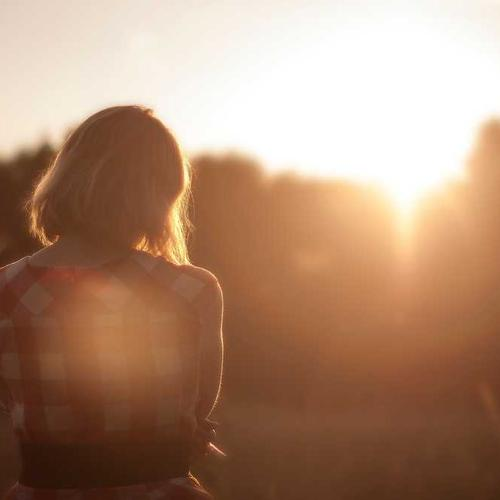


test_image_1.jpg: A woman with short hair stands with her back to the camera, wearing a checkered dress, as she gazes toward a bright, golden sunset over a blurred landscape.


In [4]:
from IPython.display import display, Image

image_dir = Path("../tests/fixtures/images")
test_images = sorted(image_dir.glob("test_image_*.jpg"))
print(f"{len(test_images)} test images available")

display(Image(test_images[0]))
desc = llm.call_llm(
    prompt="Describe this image in one detailed sentence.",
    images=[test_images[0]],  # gravel road
).result(timeout=60.0)
print(f"\n{test_images[0].name}: {desc}")

In [5]:
llm.stop()  # done with quick-start worker

---
## 3. Global Config: `temp_config()` for Environment-Specific Defaults

In [14]:
from slowburn import slowburn_config, temp_config

cfg = slowburn_config.defaults
print("Current defaults:")
print(f"  temperature:       {cfg.temperature}")
print(f"  max_tokens:        {cfg.max_tokens}")
print(f"  budget_usd:        ${cfg.budget_usd}")
print(f"  chars_per_token:   {cfg.chars_per_token}")
print(f"  safety_multiplier: {cfg.token_safety_multiplier}")

print()

# temp_config scopes overrides — everything reverts on exit
with temp_config(temperature=0.0, max_tokens=50, budget_usd=0.10):
    print(f"Inside temp_config:  temperature={slowburn_config.defaults.temperature}, "
          f"max_tokens={slowburn_config.defaults.max_tokens}, "
          f"budget_usd=${slowburn_config.defaults.budget_usd}")

print(f"After temp_config:   temperature={cfg.temperature}, "
      f"max_tokens={cfg.max_tokens}, "
      f"budget_usd=${cfg.budget_usd}  (restored)")

Current defaults:
  temperature:       0.7
  max_tokens:        1000
  budget_usd:        $5.0
  chars_per_token:   3.0
  safety_multiplier: 5.0

Inside temp_config:  temperature=0.0, max_tokens=50, budget_usd=$0.1
After temp_config:   temperature=0.7, max_tokens=1000, budget_usd=$5.0  (restored)


---
## 4. Research Agent Under Dollar Budget

This runs the **actual `demo_native_research_agent`** — a ReAct agent that:
- Searches the web with DuckDuckGo
- Takes notes by writing files to a sandboxed workspace
- Synthesizes a research report

Every LLM call is cost-tracked. When the budget is exhausted, SlowBurn blocks (backpressure) rather than crashing.

In [6]:
from datetime import datetime

# Import the shared agent loop and tools
sys.path.insert(0, str(Path(".").resolve()))
from lib.agent_loop import run_agent
from lib.tools import TOOL_SCHEMAS, execute_tool_call

BUDGET_USD = 0.01  # 1 cent per minute
BUDGET_WINDOW_SECONDS = 60
MAX_STEPS = 12

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
runs_dir = Path(f"runs/demo_notebook/{timestamp}")
runs_dir.mkdir(parents=True, exist_ok=True)

# Create a SlowBurnLLM worker — the agent uses this for every LLM call
agent_llm = create_llm(
    model=AGENT_MODEL,
    api_key=API_KEY,
    budget_usd=BUDGET_USD,
    window=BUDGET_WINDOW_SECONDS,
    max_tokens=600,
    temperature=0.3,
)

def tool_executor(name, args):
    return execute_tool_call(name, args, workspace=runs_dir)

print(f"Agent model: {AGENT_MODEL}")
print(f"Budget:      ${BUDGET_USD} per {BUDGET_WINDOW_SECONDS}s window")
print(f"Max steps:   {MAX_STEPS}")
print(f"Workspace:   {runs_dir}")

Agent model: openrouter/z-ai/glm-4.5-air
Budget:      $0.01 in 60 seconds
Max steps:   12
Workspace:   runs/demo_notebook/20260313_191441


In [8]:
RESEARCH_TASK = (
    "Research the cost of running LLM agents in production. "
    "Search the web for real data on API costs for GPT-4, Claude, and Gemini. "
    "Find specific dollar amounts from benchmarks like SWE-bench and Tau-bench. "
    "Write your findings to a file called 'cost_analysis.md' with sources."
)

SYSTEM_PROMPT = """\
You are a thorough research agent. You have access to these tools:
- search_web: Search the web with DuckDuckGo to find real information
- write_file: Save your research notes and reports to files
- read_file: Read files you've previously written
- list_dir: See what files exist in your workspace

For the research task:
1. Use search_web 2-3 times with different queries to gather information
2. Use write_file to save a structured report with real sources and URLs
3. Be specific: cite actual numbers, paper names, and URLs from search results

IMPORTANT: You MUST use search_web to find real data. Do NOT make up facts."""

print(f"Task: {RESEARCH_TASK[:80]}...")
print("\nRunning agent...\n")

start = time.time()
result = run_agent(
    llm=agent_llm,
    task=RESEARCH_TASK,
    tools=TOOL_SCHEMAS,
    tool_executor=tool_executor,
    system_prompt=SYSTEM_PROMPT,
    max_steps=MAX_STEPS,
    verbose=True,
    log_dir=runs_dir / "task_01",
)
elapsed = time.time() - start

print(f"\nAgent finished in {elapsed:.1f}s")
print(f"Steps: {result['steps']}, Tool calls: {result['tool_calls']}")
print(f"Cost: ${result['cost_usd']:.6f}")

Task: Research the cost of running LLM agents in production. Search the web for real d...

Running agent...



KeyboardInterrupt: 

    [ 1] tool: search_web({"query": "LLM agent production costs GPT-4 Claude Gemini API pricing SWE-bench Tau-bench"})
         $0.000252 | 1 LLM calls | 1 tool calls
    [ 2] tool: search_web({"query": "SWE-bench Tau-bench LLM agent costs GPT-4 Claude Gemini API pricing dollars"})
         $0.000406 | 2 LLM calls | 2 tool calls
    [ 3] tool: search_web({"query": "\"SWE-bench\" \"cost\" \"GPT-4\" \"Claude\" \"Gemini\" API pricing per token"})
         $0.000632 | 3 LLM calls | 3 tool calls
    [ 4] tool: search_web({"query": "\"SWE-bench\" cost analysis \"per task\" \"dollars\" GPT-4 Claude production"})
         $0.000840 | 4 LLM calls | 4 tool calls
    [ 5] tool: search_web({"query": "GPT-4 \"per token\" pricing \"input\" \"output\" dollars 2025 Claude Gemini API"})


### Agent's output

In [ ]:
# Show the research report the agent wrote
report_path = runs_dir / "cost_analysis.md"
if report_path.exists():
    from IPython.display import Markdown, display
    display(Markdown(report_path.read_text()))
else:
    print("Agent's final answer:")
    print(result["result"][:500])

---
## 5. Cost Report

The `CostReporter` accumulated every LLM call from the agent run.

In [ ]:
from IPython.display import Markdown, display

reporter = agent_llm.get_reporter().result(timeout=5.0)

print(f"Total LLM calls: {reporter.num_calls}")
print(f"Total cost:      ${reporter.total_cost():.6f}")
print(f"Budget used:     {reporter.total_cost() / BUDGET_USD * 100:.1f}% of ${BUDGET_USD}")
print()

# Markdown table
display(Markdown(reporter.to_markdown()))

In [ ]:
# LaTeX table (for papers)
print(reporter.to_latex())

In [ ]:
# Files the agent created
print(f"Files in workspace ({runs_dir}):")
for f in sorted(runs_dir.rglob("*")):
    if f.is_file() and not str(f.name).startswith("."):
        print(f"  {f.relative_to(runs_dir)}: {f.stat().st_size:,} bytes")

# Save cost report to JSON
json_path = reporter.to_json(path=runs_dir / "_cost_report.json")
print(f"\nCost report saved to: {json_path}")

---

**That's SlowBurn.** A real research agent ran under a $0.15 budget,
searched the web, wrote files, and every LLM call was cost-tracked.
If the budget had been exhausted, the agent would have slowed down (backpressure)
rather than crashing.